# Réplica del 2.º puesto: enfoque híbrido (Kong *et al.*, 2020)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Réplica independiente de *A Hybrid Approach of Data-driven and Physics-based Methods for Estimation
and Prediction of Fatigue Crack Growth* (Kong, Jo, Jung, Ha, Shin, Yoon, Sun, Seo y Jeon;
*International Journal of Prognostics and Health Management*, 2020), la entrada que obtuvo el 2.º
puesto del certamen con una penalización oficial de 7.63.

De las tres réplicas, esta constituye la referencia reproducible del trabajo, y por eso es la que se
emplea como término de comparación en el resto de la memoria. La razón es que su artículo es el
único que publica su predicción ciclo a ciclo para ambos especímenes, en su Tabla 3: alimentando la
penalización oficial con esos valores se obtiene 7.6308 frente al 7.63 que declara, de modo que la
métrica queda verificada de forma independiente del resto de la tubería. El 1.er puesto reporta su
error en milímetros sin normalizar y publica solo el total, aunque el desglose por espécimen sí
resulta derivable de sus tablas, y el 3.º declara 16.14 donde sus propios valores dan 16.09.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Metodología del artículo |
| 2 | Tratamiento de señal |
| 3 | Preparación del conjunto de datos |
| 4 | El modelo: parte guiada por datos y parte física |
| 5 | Ajuste |
| 6 | Resultados |
| 7 | Comparación con el artículo y con la clasificación del certamen |
| 8 | Conclusiones |
| 9 | Glosario |

> **Alcance de este informe.** Reproduce un método ajeno, no propone uno propio. Todo lo que aquí se
> mide sirve para fijar un término de comparación, y las desviaciones respecto del artículo se
> documentan una por una en el apartado 8.

In [1]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pipeline import HybridPipeline, PAPER_PREDICTIONS, PREDICTION_CYCLES
from scipy.signal import hilbert

from signal_processing import SignalPreprocessor, bandpass_filter, DT_S
from features import FEATURE_NAMES, OPTIMAL_FEATURES
from data_loader import (TRAINING_SPECIMENS, VALIDATION_SPECIMENS,
                         DATA_DRIVEN_SPECIMENS, ENSEMBLE_SPECIMENS)
from scoring import score_table, penalty_score, rmse_mm
from physics_models import linear_regression_extrapolation

pd.set_option("display.width", 200)
np.random.seed(0)

COLOR = {"T1": "#2a78d6", "T2": "#008300", "T3": "#e87ba4", "T4": "#eda100",
         "T5": "#8a8987", "T6": "#1baf7a", "T7": "#eb6834", "T8": "#4a3aa7"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "lines.linewidth": 1.6})

DATA_ROOT = Path("../PHMDC2019_Data")
pipe = HybridPipeline(DATA_ROOT)
print("Especímenes cargados:", list(pipe.specimens))
print("Usados por la parte guiada por datos:", DATA_DRIVEN_SPECIMENS, "(T5 excluido)")
print("Usados por el ensamblado físico de T7 :", ENSEMBLE_SPECIMENS)

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"

def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig

from src.referencias_phm import tabla_comparativa, desviacion


Especímenes cargados: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
Usados por la parte guiada por datos: ['T1', 'T2', 'T3', 'T4', 'T6'] (T5 excluido)
Usados por el ensamblado físico de T7 : ['T1', 'T3', 'T4', 'T6']


## 1. Metodología del artículo

El método es híbrido en un sentido preciso: emplea aprendizaje automático en los ciclos que
conservan señal y mecánica de la fractura en los que no la tienen. El punto de costura entre ambos
regímenes es el último ciclo con medición.

| Tramo | Información disponible | Método |
|---|---|---|
| Ciclos con señal de ondas de Lamb | forma de onda y estado anterior | bosque aleatorio sobre rasgos extraídos de la señal |
| Ciclos sin señal, espécimen T7 | solo la última grieta estimada | pronóstico por ensamblado: curvas doble-exponenciales de los especímenes de entrenamiento, ponderadas por verosimilitud |
| Ciclos sin señal, espécimen T8 | la misma información, con espectro de carga variable | ecuación de Walker resuelta con 100 realizaciones de Monte Carlo |

T7 y T8 reciben tratamiento distinto porque T8 es el único espécimen de amplitud variable, y el
ensamblado de curvas de T1 a T6, todas de amplitud constante, no resulta transferible a él.

## 2. Tratamiento de señal

La cadena consta de dos operaciones, en este orden:

1. **Filtrado paso banda entre 150 y 350 kHz** con un Butterworth, centrado en la excitación de unos
   200 kHz. Tras filtrar, las dos repeticiones de cada medida resultan casi idénticas, por lo que el
   artículo trabaja con una sola.
2. **Alineación de fase**, destinada a compensar las diferencias entre pares de transductores
   piezoeléctricos. El artículo alinea por el máximo del canal del actuador.

Una vez alineada la señal, el paquete principal del modo S0 queda en una ventana temporal fija, de la
que se extraen todos los rasgos. El artículo la fija mostrándola: su Figura 4 dibuja las señales
preprocesadas de T4 sobre el tramo del que dice haber extraído los rasgos. El eje de esa figura está
mal rotulado, porque imprime valores de 10.6 a 12.6 con la unidad `µs` y en estos registros la propia
ráfaga de actuación ya alcanza su máximo cerca de los 82 µs. Leídos en unidades de 10⁻⁵ s los
valores dan 106 a 126 µs, y esa lectura es la que sostiene la medida: promediando la envolvente de
todas las señales recibidas, la diafonía de la actuación decae hacia los 95 µs, el primer paquete
propagado asciende desde los 106 µs y a partir de los 130 µs lo dominan las llegadas posteriores. La
ventana adoptada es por tanto la de la figura, 106 a 126 µs.

La celda siguiente dibuja la señal completa de un espécimen y el tramo ventaneado a lo largo de su
vida, para comprobar sobre la propia medida que la ventana cae dentro del paquete.

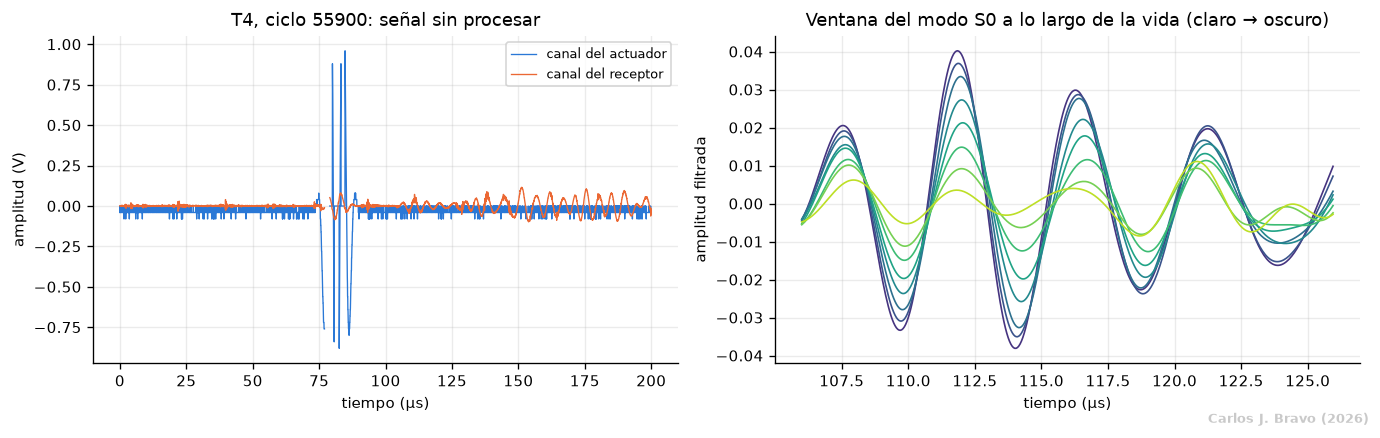

In [2]:
demo_esp, demo_ciclo = "T4", 55900
df_raw = pipe.specimens[demo_esp].signal(demo_ciclo)
t_us = df_raw["time"].to_numpy() * 1e6

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].plot(t_us, df_raw["ch1"], lw=0.8, color="#2a78d6", label="canal del actuador")
axes[0].plot(t_us, df_raw["ch2"], lw=0.8, color="#eb6834", label="canal del receptor")
axes[0].set(xlabel="tiempo (µs)", ylabel="amplitud (V)",
            title=f"{demo_esp}, ciclo {demo_ciclo}: señal sin procesar")
axes[0].legend(fontsize=7.5)

from features import FeatureExtractor 
_extractor_demo = FeatureExtractor()
_extractor_demo.set_alignment_anchor(pipe.specimens)
ventanas = _extractor_demo.specimen_windows(pipe.specimens[demo_esp])
tw = _extractor_demo.preprocessor.window_times_s(4000) * 1e6
ciclos = pipe.specimens[demo_esp].labeled_cycles()
cmap = plt.get_cmap("viridis")
for i, c in enumerate(ciclos):
    axes[1].plot(tw, ventanas[c], lw=1.0, color=cmap(0.15 + 0.75 * i / max(1, len(ciclos) - 1)))
axes[1].set(xlabel="tiempo (µs)", ylabel="amplitud filtrada",
            title="Ventana del modo S0 a lo largo de la vida (claro → oscuro)")
fig.tight_layout()
marca_de_agua(fig)
plt.show()


## 3. Preparación del conjunto de datos

De cada ventana se extraen ocho rasgos candidatos, siempre por comparación con la referencia sin daño
del mismo espécimen. Se agrupan en tres familias, cada una con su interpretación física, más el
contexto secuencial:

| Familia | Fenómeno físico | Rasgos |
|---|---|---|
| Pérdida de energía | la grieta refleja parte del paquete transmitido | `max_amplitude`, `max_energy`, `dtw_residual_energy` |
| Cambio de fase | la dispersión alarga el camino recorrido | `xcorr_lag`, `phase_delay`, `dtw_distance` |
| Pérdida de similitud | la discontinuidad distorsiona la forma de onda | `corr_coef` |
| Contexto secuencial | no corresponde a un fenómeno de la señal | `prev_crack`, la grieta estimada en el ciclo anterior |

El artículo selecciona cinco de ellos como subconjunto óptimo, y la réplica los adopta por replicidad.

In [3]:
print(f"Rasgos candidatos ({len(FEATURE_NAMES)}):")
for n in FEATURE_NAMES:
    print("   -", n)
print(f"\nSubconjunto óptimo del artículo ({len(OPTIMAL_FEATURES)}): {', '.join(OPTIMAL_FEATURES)}")

todos = pipe.build_feature_tables()
print(f"\nFilas de la tabla de rasgos: {len(todos)}")
display(todos.head(8).round(4))


Rasgos candidatos (8):
   - max_amplitude
   - max_energy
   - dtw_residual_energy
   - xcorr_lag
   - phase_delay
   - dtw_distance
   - corr_coef
   - prev_crack

Subconjunto óptimo del artículo (5): max_amplitude, max_energy, phase_delay, corr_coef, prev_crack



Filas de la tabla de rasgos: 45


,specimen,cycle,max_amplitude,max_energy,dtw_residual_energy,xcorr_lag,phase_delay,dtw_distance,corr_coef,prev_crack,crack_length_mm
0,T1,50000,0.0405,0.0754,0.0000,0.00,0.0,0.0000,1.0000,0.00,0.00
1,T1,60000,0.0343,0.0554,0.0064,-0.75,-0.2,0.5608,0.3081,0.00,2.18
2,T1,62500,0.0343,0.0564,0.0062,-0.65,0.1,0.5414,0.4403,2.18,2.76
3,T1,65500,0.0375,0.0679,0.0060,-0.40,0.7,0.5080,0.5939,2.76,3.51
4,T1,69025,0.0272,0.0351,0.0077,-0.40,0.4,0.6376,0.6189,3.51,4.51
5,T1,70026,0.0235,0.0258,0.0091,-0.35,0.4,0.7085,0.6370,4.51,4.90
6,T1,70766,0.0123,0.0069,0.0185,-0.50,-2.4,1.0104,0.4680,4.90,7.46
7,T2,50000,0.0300,0.0433,0.0001,-0.05,-0.1,0.0921,0.9960,0.00,0.00


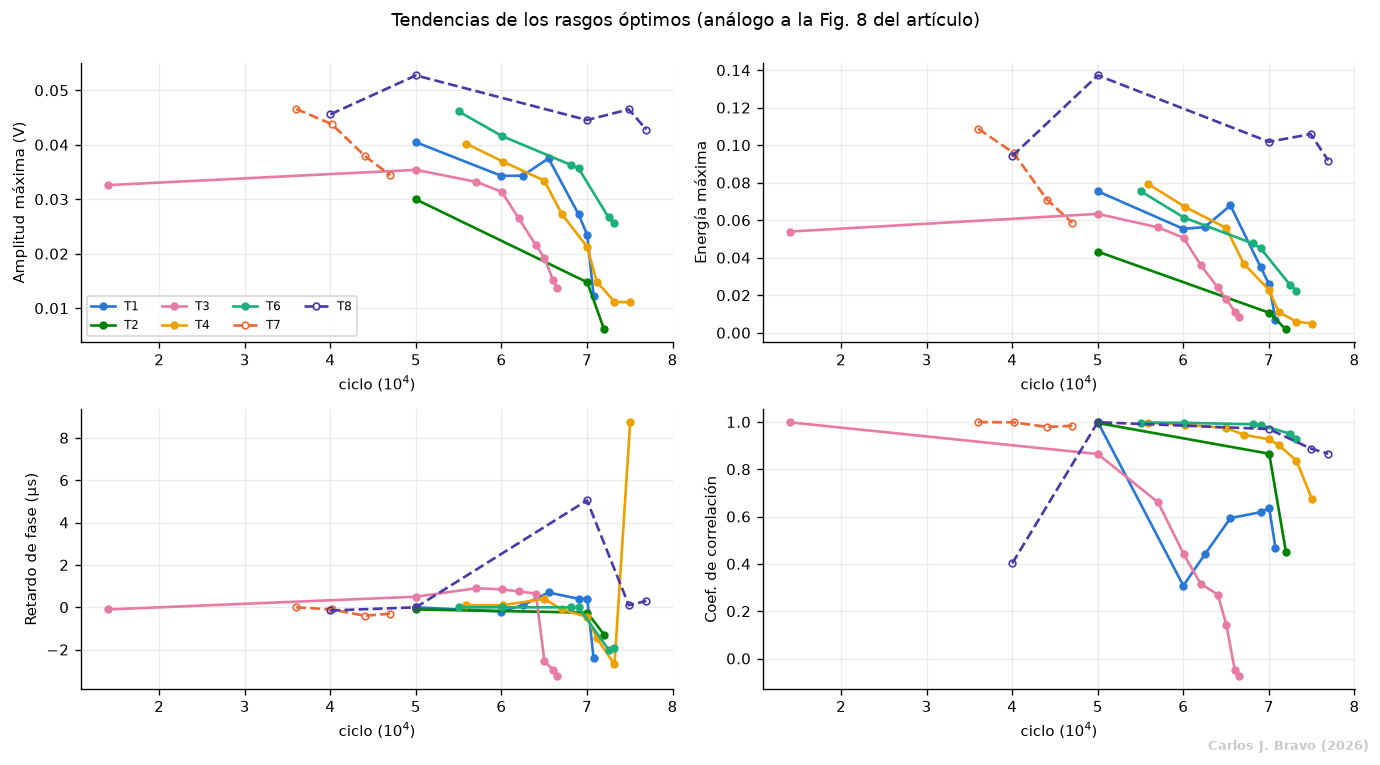

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.2))
paneles = [("max_amplitude", "Amplitud máxima (V)"), ("max_energy", "Energía máxima"),
           ("phase_delay", "Retardo de fase (µs)"), ("corr_coef", "Coef. de correlación")]
for ax, (rasgo, etiqueta) in zip(axes.ravel(), paneles):
    for n in ["T1", "T2", "T3", "T4", "T6", "T7", "T8"]:
        sub = todos[todos.specimen == n]
        estilo = dict(ls="--", marker="o", mfc="none") if n in ("T7", "T8") else dict(ls="-", marker="o")
        ax.plot(sub.cycle / 1e4, sub[rasgo], color=COLOR[n], label=n, ms=4, **estilo)
    ax.set(xlabel="ciclo (10$^4$)", ylabel=etiqueta)
axes[0, 0].legend(fontsize=7, ncol=4)
fig.suptitle("Tendencias de los rasgos óptimos (análogo a la Fig. 8 del artículo)", y=1.0)
fig.tight_layout(); marca_de_agua(fig)
plt.show()


## 4. El modelo

### 4.1 Parte guiada por datos (Data-Driven)

Se emplea un bosque aleatorio con búsqueda en rejilla sobre la profundidad máxima y el número de
árboles, minimizando el error medio al dejar fuera un espécimen completo. La partición se hace por
espécimen y no por ciclos sueltos, porque dejar fuera ciclos aislados filtraría información entre
particiones: el contexto secuencial de un ciclo procede del ciclo contiguo.

La predicción del espécimen excluido es recursiva, dado que uno de los rasgos consume la estimación
del ciclo anterior, igual que ocurre después al predecir T7 y T8. La entrega final promedia un
ensamblado de veinte bosques con semillas independientes.

### 4.2 Parte física

Para **T7** se aplica un pronóstico por ensamblado. Se ajusta una curva doble-exponencial a cada
espécimen de entrenamiento y, en cada paso, se pondera cada curva por una densidad gaussiana centrada
en su valor actual y evaluada en la grieta actual de T7, prediciendo con la suma ponderada. El
esquema equivale a un filtro de partículas en el que las partículas son las curvas.

Para **T8** se emplea la ecuación de Walker. Sus cuatro parámetros, `C0`, `gamma`, `m` y
`sigma_FC`, se ajustan por optimización evolutiva repetida cien veces desde poblaciones iniciales
aleatorias, y la predicción es la media de las cien curvas. Conviene precisar que esas cien
realizaciones no llevan ruido añadido: lo que varía entre ellas es el punto de partida del
optimizador, no los datos.

Once decisiones quedan sin enunciar en el texto del artículo, y esta réplica las adopta de forma
explícita. El apartado 8 las lista una a una, dice de dónde sale cada valor y mide las que mueven el
resultado. Dos
se leen de las figuras del propio artículo, otras dos se fijan con criterios derivados solo de los
especímenes de entrenamiento, y el resto son decisiones de implementación sin respaldo publicado.

## 5. Ajuste

In [5]:
tabla_entrenamiento = pipe.training_table()
t0 = time.perf_counter()
mejor = pipe.estimator.grid_search(tabla_entrenamiento)
t_busqueda = time.perf_counter() - t0
print(f"Búsqueda en rejilla: {t_busqueda:.1f} s")
print(f"Óptimo: profundidad máxima = {mejor.max_depth}, árboles = {mejor.n_trees}, "
      f"métrica = {mejor.pm:.3f}")
print("Error por partición (un espécimen fuera cada vez):")
for k, v in mejor.fold_rmse.items():
    print(f"   {k}: {v:.3f} mm")


Búsqueda en rejilla: 9.8 s
Óptimo: profundidad máxima = 2, árboles = 25, métrica = 1.100
Error por partición (un espécimen fuera cada vez):
   T1: 1.096 mm
   T2: 1.012 mm
   T3: 1.084 mm
   T4: 0.905 mm
   T6: 1.400 mm


In [6]:
print("El modelo usa el subconjunto de rasgos que publica el artículo:")
for r in OPTIMAL_FEATURES:
    print(f"   {r}")


El modelo usa el subconjunto de rasgos que publica el artículo:
   max_amplitude
   max_energy
   phase_delay
   corr_coef
   prev_crack


In [7]:
t0 = time.perf_counter()
resultados = pipe.run(max_depth=mejor.max_depth, n_trees=mejor.n_trees)
t_total = time.perf_counter() - t0
print(f"Pipeline completo (estimación + física de T7 y T8): {t_total:.1f} s")
display(resultados.round(3))


Pipeline completo (estimación + física de T7 y T8): 27.0 s


,specimen,cycle,estimated_crack_mm,raw_ensemble_mm,method,true_crack_mm,paper_prediction_mm
0,T7,36001,0.000,0.261,data-driven,0.00,0.000
1,T7,40167,0.000,0.261,data-driven,0.00,0.000
2,T7,44054,1.758,1.758,data-driven,2.07,2.175
3,T7,47022,2.367,2.367,data-driven,3.14,3.017
4,T7,49026,2.690,NaN,physics-based,3.56,3.423
5,T7,51030,3.021,NaN,physics-based,4.13,4.310
6,T7,53019,3.614,NaN,physics-based,5.05,5.547
7,T7,55031,4.905,NaN,physics-based,7.22,7.170
8,T8,40000,0.000,1.781,data-driven,0.00,0.000
9,T8,50000,0.000,0.625,data-driven,0.00,0.000


## 6. Resultados

In [8]:
resumen = pipe.summary()
display(resumen.round(4))

tablas = pipe.score_tables()
for n, tab in tablas.items():
    print(f"\n--- {n}: penalización S = {tab.S.sum():.3f}   "
          f"(desglose por ciclo: S(i) = T(i)·A(i)·M(i))")
    display(tab.round(4))


,specimen,rmse_mm,penalty,paper_rmse_mm,paper_penalty
0,T7,1.1237,83.2523,0.2021,3.5430
1,T8,1.1630,148.3436,0.5571,4.0878
2,total,NaN,231.5959,NaN,7.6308



--- T7: penalización S = 83.252   (desglose por ciclo: S(i) = T(i)·A(i)·M(i))


,cycle,estimated_norm,true_norm,T,A,M,S
0,36001,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
1,40167,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
2,44054,0.2435,0.2867,4.8670,0.2409,1.0,1.1725
3,47022,0.3279,0.4349,6.3490,0.7079,1.0,4.4943
4,49026,0.3726,0.4931,6.9307,0.8265,1.0,5.7284
5,51030,0.4184,0.5720,7.7202,1.1552,1.0,8.9185
6,53019,0.5006,0.6994,8.9945,1.7031,1.0,15.3183
7,55031,0.6794,1.0000,12.0000,3.9684,1.0,47.6202



--- T8: penalización S = 148.344   (desglose por ciclo: S(i) = T(i)·A(i)·M(i))


,cycle,estimated_norm,true_norm,T,A,M,S
0,40000,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
1,50000,0.0000,0.0000,2.0000,0.0000,1.0,0.0000
2,70000,0.3350,0.0000,2.0000,0.9544,1.0,1.9088
3,74883,0.3752,0.3514,5.5145,0.0487,1.0,0.2688
4,76931,0.3999,0.4529,6.5290,0.3032,1.0,1.9793
5,89237,0.5076,0.6721,8.7210,1.2763,1.0,11.1307
6,92315,0.5398,0.7029,9.0290,1.2601,1.0,11.3777
7,96475,0.5866,0.8351,10.3514,2.4643,1.0,25.5089
8,98492,0.6108,0.8986,10.9855,3.2158,1.0,35.3267
9,100774,0.6393,1.0000,12.0000,5.0702,1.0,60.8426


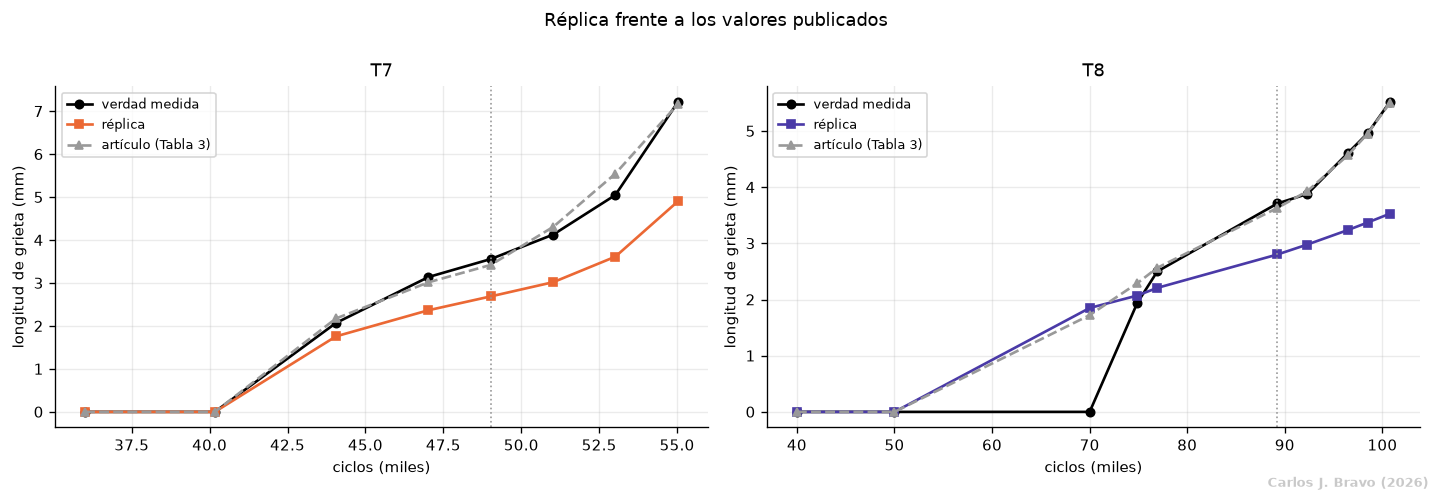

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, n in zip(axes, ("T7", "T8")):
    r = resultados[resultados.specimen == n]
    ax.plot(r.cycle / 1e3, r.true_crack_mm, "ko-", ms=5, label="verdad medida")
    ax.plot(r.cycle / 1e3, r.estimated_crack_mm, "s-", color=COLOR[n], ms=5, label="réplica")
    ciclos_p = sorted(PAPER_PREDICTIONS[n])
    ax.plot(np.array(ciclos_p) / 1e3, [PAPER_PREDICTIONS[n][c] for c in ciclos_p],
            "^--", color="#999", ms=5, label="artículo (Tabla 3)")
    ax.axvline(PREDICTION_CYCLES[n][0] / 1e3, color="0.6", ls=":", lw=1)
    ax.set(xlabel="ciclos (miles)", ylabel="longitud de grieta (mm)", title=n)
    ax.legend(fontsize=7.5)
fig.suptitle("Réplica frente a los valores publicados", y=1.0)
fig.tight_layout(); marca_de_agua(fig)
plt.show()


## 7. Comparación con el artículo y con la clasificación del certamen

### 7.1 Verificación de la métrica

Antes de comparar resultados procede demostrar que la penalización está correctamente implementada.
La comprobación consiste en alimentarla con las predicciones que publican los propios autores en su
Tabla 3: si la implementación es correcta, debe devolver la cifra que ellos reportan.

> **Una incoherencia menor del artículo.** Su resumen declara un error cuadrático medio de 0.2021
> para T7 y de 0.551 para T8. Alimentando sus propios valores de la Tabla 3, T7 sale exacto, 0.2021,
> pero T8 da 0.5571. Que T7 cuadre al cuarto decimal y T8 no descarta que se trate de un criterio de
> cálculo distinto, y apunta a una errata de transcripción en el 0.551. No afecta a la penalización,
> que sí se reproduce, pero significa que no todas las cifras publicadas son reproducibles a partir
> de las tablas del propio artículo.

In [10]:
comprobacion = []
for n in ("T7", "T8"):
    ciclos = sorted(PAPER_PREDICTIONS[n])
    hat = [PAPER_PREDICTIONS[n][c] for c in ciclos]
    real = [pipe.specimens[n].crack_length(c) for c in ciclos]
    comprobacion.append({"espécimen": n, "RMSE (mm)": rmse_mm(hat, real),
                         "penalización": penalty_score(ciclos, hat, real)})
comprobacion = pd.DataFrame(comprobacion)
display(comprobacion.round(4))
total = comprobacion["penalización"].sum()
print(f"Penalización total reproducida a partir de los valores publicados: {total:.2f}")
print(f"Penalización que reporta el artículo                             : 7.63")
print(f"Desviación relativa: {100*abs(total-7.63)/7.63:.2f} %")
print("\nLa métrica está correctamente implementada, de modo que cualquier diferencia")
print("posterior procede del método replicado y no del sistema de puntuación.")


,espécimen,RMSE (mm),penalización
0,T7,0.2021,3.5430
1,T8,0.5571,4.0878


Penalización total reproducida a partir de los valores publicados: 7.63
Penalización que reporta el artículo                             : 7.63
Desviación relativa: 0.01 %

La métrica está correctamente implementada, de modo que cualquier diferencia
posterior procede del método replicado y no del sistema de puntuación.


### 7.2 La réplica frente al artículo y frente a la clasificación

In [11]:
PUESTO = "2.º Kong et al. (2020)"
propia = {"T7": float(resumen.penalty[0]), "T8": float(resumen.penalty[1])}

tabla = tabla_comparativa(PUESTO, propia)
display(tabla)
print("Menor es mejor en las tres columnas numéricas.")
print()
print("Las tres primeras filas no son cifras que sus autores impriman por espécimen: ninguno de los")
print("tres artículos publica ese desglose. Se obtienen aplicando la penalización oficial a las")
print("predicciones que sí publican en sus tablas, y sus totales declarados son 7.36, 7.63 y 16.14.")
print()
print("Las tres últimas son lo que alcanza la reimplementación de cada método en este trabajo. La de")
print(f"este cuaderno se recalcula al ejecutarlo; las otras dos proceden de sus cuadernos respectivos.")
d = desviacion(PUESTO, propia)
print(f"\nDesviación entre lo recalculado aquí y lo registrado en referencias_phm.py: {d:.3f}")
if d > 0.01:
    print("No coinciden: hay que actualizar REPLICA en referencias_phm.py con la cifra de arriba.")


,T7,T8,total,naturaleza
entrada,,,,
1.º Youn et al. (2019),3.415,3.944,7.359,"publicada, derivada de sus Tablas 5, 7, 8 y 11"
2.º Kong et al. (2020),3.543,4.088,7.631,"publicada, derivada de su Tabla 3"
3.º Rao et al. (2020),9.229,6.864,16.093,"publicada, derivada de su Tabla A"
"1.º Youn et al. (2019), réplica",22.708,91.600,114.309,"reproducible, su cuaderno"
"2.º Kong et al. (2020), réplica",83.252,148.344,231.596,"reproducible, este cuaderno"
"3.º Rao et al. (2020), réplica",215.123,25.787,240.910,"reproducible, su cuaderno"


Menor es mejor en las tres columnas numéricas.

Las tres primeras filas no son cifras que sus autores impriman por espécimen: ninguno de los
tres artículos publica ese desglose. Se obtienen aplicando la penalización oficial a las
predicciones que sí publican en sus tablas, y sus totales declarados son 7.36, 7.63 y 16.14.

Las tres últimas son lo que alcanza la reimplementación de cada método en este trabajo. La de
este cuaderno se recalcula al ejecutarlo; las otras dos proceden de sus cuadernos respectivos.

Desviación entre lo recalculado aquí y lo registrado en referencias_phm.py: 0.000


## 8. Conclusiones

### 8.1 Alcance de la reproducción

Se replicaron todas las etapas del método publicado: el preprocesado, con su filtrado paso banda y su
alineación de fase; los ocho rasgos con sus mismas interpretaciones físicas; la estandarización; el
bosque aleatorio con búsqueda en rejilla y validación por espécimen, excluido T5; el ensamblado de
veinte modelos; la estimación recursiva; la normalización de ciclos; el pronóstico por ensamblado con
pesos de tipo filtro de partículas para T7; la ecuación de Walker con optimización evolutiva y cien
realizaciones de Monte Carlo para T8; y la penalización oficial, que reproduce el 7.63 del artículo
al alimentarla con sus propios valores.

La **búsqueda del subconjunto de rasgos** también se reproduce, y de forma más amplia que en el
artículo: donde este selecciona cinco de los ocho comparando el PM de subconjuntos elegidos al azar,
el apartado 8.3 recorre exhaustivamente los 210 subconjuntos de tamaño 3 a 6, que contienen ese
muestreo. El modelo, en cambio, conserva los cinco rasgos publicados con independencia de lo que
arroje la búsqueda: cambiarlos sería dejar de replicar el método.

### 8.2 Decisiones que el artículo no enuncia

Son once, y se agrupan por el respaldo que tiene cada una.

**Fijadas por las figuras del propio artículo**

1. **Ventana del modo S0, de 106 a 126 µs.** Es el tramo que dibuja su Figura 4. El eje de esa figura
   está mal rotulado, con valores de 10.6 a 12.6 y la unidad `µs`, y no puede leerse literal porque
   la ráfaga de actuación ya pica hacia los 82 µs. Leído en unidades de 10⁻⁵ s coincide con lo que
   mide la señal: promediando la envolvente de los 46 registros recibidos, la diafonía decae hacia
   los 95 µs, el primer paquete propagado sube desde los 106 µs y desde los 130 µs mandan las
   llegadas posteriores.
2. **Desviación típica de las gaussianas del filtro de partículas, 1.0 mm.** Su Figura 7 las dibuja
   con una probabilidad de pico de 0.4, y una gaussiana de pico `1/(sigma*sqrt(2*pi)) = 0.4` tiene
   `sigma = 1.0`.

**Fijadas por criterios derivados solo de los especímenes de entrenamiento**

3. **Umbral de detección de la iniciación, 0.82 mm**, la menor grieta que algún espécimen de
   entrenamiento presenta en su primer ciclo dañado, que es T6. No interviene T7 ni T8. El propio
   artículo acota por arriba este umbral: reporta 1.722 mm en el ciclo 70000 de T8 y declara ese
   mismo ciclo como su `N_initial`, de modo que cualquier umbral por encima de 1.722 mm aplicado a
   sus cifras publicadas desplazaría su `N_initial` al 74883.
4. **Cota superior de las tasas de la Ec. 6, 5.68·10⁻⁴ por ciclo**, la mayor tasa `d(ln a)/dN` que
   se observa entre dos puntos consecutivos de las curvas de entrenamiento. Atarla al dato impide
   que un componente crezca más rápido de lo que ninguna grieta medida creció, que es la patología a
   la que este ajuste tiende: con una cota holgada el óptimo de mínimos cuadrados de T1 aloja una
   amplitud de 2.7·10⁻⁷ mm sobre una tasa clavada en el tope, reproduce sus seis puntos y luego trepa
   de 4.28 a 8.44 mm en los dos mil ciclos que se extrapolan.
5. **Registro que sirve de patrón de alineación, el ciclo 55000 de T6.** Se elige por el PM sobre
   particiones de entrenamiento, que es el criterio de selección del propio artículo y no toca
   ningún espécimen de validación. El apartado 8.3 mide hasta qué punto esa elección pesa.

**Decisiones de implementación sin respaldo publicado**

6. **Consenso de alineación por espécimen.** La geometría de medida no cambia dentro de un espécimen,
   así que el retardo tiene que ser constante: en siete de los ocho la dispersión es de 0 a 1
   muestra. El único atípico es el ciclo 50000 de T3, que la correlación cruzada engancha 196
   muestras, esto es 9.8 µs, fuera del resto, casi media ventana. Ese registro se alinea con el
   consenso del espécimen. Es un enganche de lóbulo equivocado y no un retardo real: sin el
   consenso, el coeficiente de correlación de ese ciclo, cuya grieta es nula, sale 0.42 en lugar
   del 0.86 que le corresponde.
7. **Referencia sin daño tomada de la segunda repetición.** El conjunto de datos publicado no incluye
   las carpetas de línea base del ciclo cero que menciona su documentación, así que la referencia es
   el primer ciclo medido, y para que sea un registro independiente se usa su segunda repetición. El
   §3.2.1 del artículo dice haber empleado solo las primeras medidas, de modo que es una desviación.
   **T1 es la excepción y arrastra una fila degenerada**: sus dos repeticiones del ciclo 50000
   correlacionan 0.20 dentro de la ventana, por debajo del 0.9 exigido, y T1 no tiene ningún otro
   ciclo sin grieta al que recurrir, así que cae en autorreferencia. Su fila de referencia sale con
   correlación 1.0 y retardo 0 por construcción, y el resto de sus filas se comparan contra un
   registro que no representa bien al espécimen. La alternativa de excluir T1 del conjunto de
   entrenamiento se resuelve con el criterio libre de fuga, que la rechaza: sin T1 el PM sube de
   1.12 a 1.29. Se mantiene por tanto el conjunto de entrenamiento del artículo y se declara la
   anomalía.
8. **Retardo de fase medido sobre el pico de la envolvente**, por transformada de Hilbert, en lugar
   del máximo absoluto, que salta un período completo de la portadora entre registros.
9. **Alineación por correlación cruzada** contra el patrón, en lugar del máximo del canal del
   actuador que enuncia el artículo, porque la ráfaga tiene varios lóbulos de amplitud casi igual y
   un máximo simple salta entre ellos.
10. **Tres constantes de cálculo de rasgos**: el índice 1700 como origen común de la alineación, la
    ventana de 100 muestras de la energía instantánea y la decimación por 4 de las series antes del
    alineamiento temporal dinámico.
11. **La forma concreta de la Ec. 12 y de las cotas de Walker.** El artículo solo dice que su función
    objetivo es un error cuadrático medio `con más peso en las grietas de los ciclos tardíos`: los
    pesos `i²` son lectura de esta réplica. Las cotas `C0 ∈ [10⁻¹², 10⁻⁸]`, `gamma ∈ [0, 1]`,
    `m ∈ [2, 4]` y `sigma_FC ∈ [−0.5, 0.5]` tampoco están publicadas. Y `sigma_FC`, que el artículo
    enuncia como una incertidumbre, aquí está implementado como un desplazamiento con signo que el
    optimizador ajusta, que no es lo mismo.

Dos desviaciones más, de menor alcance. El factor de monotonía se implementa como
`1 + 10*|x_i - x_(i-1)|`, con valor absoluto, mientras que la Ec. 3 impresa daría `1 + 10*(x_i -
x_(i-1))` con diferencia negativa, es decir un factor menor que 1 que premiaría la no monotonía; el
valor absoluto es la lectura correcta y coincide con la hoja oficial del certamen. Y la optimización
usa evolución diferencial, que el artículo llama algoritmo genético: es evolutiva, pero muta por
diferencias de vectores y no por cruce y selección.

### 8.3 Lo que de verdad decide el resultado

Tres medidas, en orden de efecto.

**El patrón de alineación.** Es una constante de implementación sin ningún contenido físico, y sin
embargo la penalización total se mueve entre 111 y 440 según cuál se elija, mientras el PM sobre
entrenamiento apenas se mueve entre 1.10 y 1.28 y **no ordena igual**. No hay señal en el lado del
entrenamiento con la que fijarlo, de modo que se fija por PM y se declara el barrido.

**La cota del exponente de Walker.** El exponente se clava en 2.000 en los cien ajustes, esto es, en
el borde inferior de una cota que esta réplica inventó. Eso invita a pensar que la cota está
mandando, pero la medida dice lo contrario: relajarla no mejora, empeora, y la saturación
simplemente se traslada a `C0`. Con `m ∈ [1, 4]` el total sube de 231.6 a 239.4, y con `m ∈ [0.5, 6]`
a 241.2. La saturación no es un artefacto de una cota mal puesta: es el modelo avisando de que las
anclas que se le dan no describen un crecimiento acelerado.

**La degeneración del ajuste de Walker.** De los cuatro parámetros, uno queda determinado, `C0` en
una banda del 10 %, y los otros tres no: `m` saturado, `sigma_FC` idéntico en los cien ajustes y
`gamma` recorriendo prácticamente todo su intervalo sin efecto sobre la curva. Las cien
realizaciones que el artículo presenta como captura de la incertidumbre producen aquí cien curvas
casi iguales.

In [12]:
import physics_models as pm
from crack_estimator import RandomForestCrackEstimator
from features import FeatureExtractor
from data_loader import DATA_DRIVEN_SPECIMENS

ANCLAS = [("T1", 50000), ("T2", 50000), ("T3", 14000),
          ("T4", 55900), ("T6", 55000), ("T7", 36001)]

filas = []
for nombre, ciclo in ANCLAS:
    fe = FeatureExtractor()
    fe.preprocessor.set_reference(pipe.specimens[nombre].signal(ciclo)["ch1"].to_numpy())
    tablas = {k: fe.specimen_feature_table(s, labeled_only=k not in ("T7", "T8"))
              for k, s in pipe.specimens.items()}
    entren = pd.concat([tablas[k] for k in DATA_DRIVEN_SPECIMENS], ignore_index=True)
    mejor = RandomForestCrackEstimator(OPTIMAL_FEATURES).grid_search(entren, OPTIMAL_FEATURES)

    otro = HybridPipeline(DATA_ROOT)
    patron = pipe.specimens[nombre].signal(ciclo)["ch1"].to_numpy()
    otro.extractor.set_alignment_anchor = (
        lambda *_a, _p=patron, **_k: otro.extractor.preprocessor.set_reference(_p))
    otro.run()
    r = otro.summary().set_index("specimen")
    filas.append({"patrón de alineación": f"{nombre} ciclo {ciclo}",
                  "PM (entrenamiento)": round(mejor.pm, 4),
                  "T7": round(float(r.loc["T7", "penalty"]), 2),
                  "T8": round(float(r.loc["T8", "penalty"]), 2),
                  "total": round(float(r.loc["total", "penalty"]), 2)})

barrido_ancla = pd.DataFrame(filas).set_index("patrón de alineación")
display(barrido_ancla.sort_values("PM (entrenamiento)"))
print("Menor es mejor en las cuatro columnas. Se adopta el de menor PM, que es el criterio del")
print("artículo y no toca T7 ni T8.")
print(f"PM recorre {barrido_ancla['PM (entrenamiento)'].min():.4f} a "
      f"{barrido_ancla['PM (entrenamiento)'].max():.4f}, un {100 * (barrido_ancla['PM (entrenamiento)'].max() / barrido_ancla['PM (entrenamiento)'].min() - 1):.0f} %; "
      f"la penalización total recorre {barrido_ancla['total'].min():.0f} a {barrido_ancla['total'].max():.0f}, "
      f"un factor {barrido_ancla['total'].max() / barrido_ancla['total'].min():.1f}.")
orden_pm = list(barrido_ancla.sort_values("PM (entrenamiento)").index)
orden_pen = list(barrido_ancla.sort_values("total").index)
print(f"Y no ordenan igual: por PM {orden_pm[0]} va primero, por penalización {orden_pen[0]}.")


,PM (entrenamiento),T7,T8,total
patrón de alineación,,,,
T6 ciclo 55000,1.0995,83.25,148.34,231.60
T1 ciclo 50000,1.1021,12.33,180.60,192.93
T7 ciclo 36001,1.1555,105.43,17.58,123.01
T2 ciclo 50000,1.1672,85.08,368.77,453.85
T4 ciclo 55900,1.1755,11.16,355.34,366.50
T3 ciclo 14000,1.2796,113.15,70.19,183.34


Menor es mejor en las cuatro columnas. Se adopta el de menor PM, que es el criterio del
artículo y no toca T7 ni T8.
PM recorre 1.0995 a 1.2796, un 16 %; la penalización total recorre 123 a 454, un factor 3.7.
Y no ordenan igual: por PM T6 ciclo 55000 va primero, por penalización T7 ciclo 36001.


In [13]:
base = list(pm.WalkerMonteCarlo.BOUNDS)
filas = []
for lo, hi in ((2.0, 4.0), (1.0, 4.0), (0.5, 6.0)):
    pm.WalkerMonteCarlo.BOUNDS = base[:2] + [(lo, hi)] + base[3:]
    otro = HybridPipeline(DATA_ROOT)
    otro.run()
    r = otro.summary().set_index("specimen")
    ajustes = np.array([f.m for f in otro.t8_walker.fits])
    filas.append({"cota de m": f"[{lo}, {hi}]",
                  "m ajustada (mediana)": round(float(np.median(ajustes)), 3),
                  "T7": round(float(r.loc["T7", "penalty"]), 2),
                  "T8": round(float(r.loc["T8", "penalty"]), 2),
                  "total": round(float(r.loc["total", "penalty"]), 2)})
pm.WalkerMonteCarlo.BOUNDS = base

display(pd.DataFrame(filas).set_index("cota de m"))
print("Menor es mejor. La primera fila es la adoptada. Relajar la cota no mejora: el exponente")
print("sigue saturando en el borde inferior que se le dé y la saturación se traslada al coeficiente.\n")

ajustes = pipe.t8_walker.fits
print("Identificabilidad de los cuatro parámetros de Walker sobre los cien ajustes:")
for nombre, valores in (("C0", [f.c0 for f in ajustes]), ("gamma", [f.gamma for f in ajustes]),
                        ("m", [f.m for f in ajustes]), ("sigma_FC", [f.sigma_fc for f in ajustes])):
    v = np.array(valores)
    recorrido = (v.max() - v.min()) / abs(np.median(v)) if np.median(v) else 0.0
    print(f"   {nombre:9s} {v.min():.5g} a {v.max():.5g}   recorrido relativo {recorrido:7.1%}")
print("\nSolo el coeficiente queda determinado. Las cien realizaciones que el artículo presenta")
print("como captura de la incertidumbre producen aquí cien curvas casi iguales.")


,m ajustada (mediana),T7,T8,total
cota de m,,,,
"[2.0, 4.0]",2.000,83.25,148.34,231.60
"[1.0, 4.0]",1.000,83.25,156.15,239.41
"[0.5, 6.0]",0.759,83.25,157.92,241.17


Menor es mejor. La primera fila es la adoptada. Relajar la cota no mejora: el exponente
sigue saturando en el borde inferior que se le dé y la saturación se traslada al coeficiente.

Identificabilidad de los cuatro parámetros de Walker sobre los cien ajustes:
   C0        7.0889e-10 a 7.8222e-10   recorrido relativo   10.1%
   gamma     0.0040436 a 0.96339   recorrido relativo  416.5%
   m         2 a 2   recorrido relativo    0.0%
   sigma_FC  0.057842 a 0.057919   recorrido relativo    0.1%

Solo el coeficiente queda determinado. Las cien realizaciones que el artículo presenta
como captura de la incertidumbre producen aquí cien curvas casi iguales.


**El subconjunto de rasgos publicado.** La celda siguiente ejecuta la búsqueda exhaustiva y lo
sitúa en mitad de tabla. Recorre los 210 subconjuntos de tamaño 3 a 6, cada uno con su rejilla
completa de hiperparámetros y su PM promediado sobre cinco bosques, de modo que es la celda más
costosa del cuaderno. El resultado no es un reproche al artículo: sus autores seleccionaron sobre
los valores que producía **su** ventaneo y **su** registro de línea base, que el conjunto publicado
no incluye, de modo que los ocho rasgos no significan aquí lo mismo que allí. Lo que la medida
establece es hasta qué punto esa etapa del método depende de un preprocesado que no se publicó.

In [14]:
t0 = time.perf_counter()
ranking = RandomForestCrackEstimator(OPTIMAL_FEATURES).feature_selection(
    tabla_entrenamiento, FEATURE_NAMES, subset_sizes=(3, 4, 5, 6))
ranking["publicado"] = ranking["features"].apply(
    lambda f: set(f.split(", ")) == set(OPTIMAL_FEATURES))
ranking["conjunto"] = ranking["features"].apply(lambda f: set(f.split(", ")))
print(f"Búsqueda exhaustiva de rasgos: {(time.perf_counter() - t0) / 60:.1f} min\n")

pos = int(ranking.index[ranking["publicado"]][0]) + 1
mejor, publicado = ranking.iloc[0], ranking[ranking["publicado"]].iloc[0]
print(f"Subconjuntos evaluados: {len(ranking)}   PM menor es mejor")
print(f"   mejor      PM {mejor['pm']:.4f}   {mejor['features']}")
print(f"   publicado  PM {publicado['pm']:.4f}   {publicado['features']}")
print(f"   mediana    PM {ranking['pm'].median():.4f}")
print(f"\nEl subconjunto que publica el artículo queda en la posición {pos} de {len(ranking)}, "
      f"un {100 * (publicado['pm'] / mejor['pm'] - 1):.0f} % por encima del mejor.")

filas = []
for rasgo in FEATURE_NAMES:
    con = ranking[ranking["conjunto"].apply(lambda s: rasgo in s)]
    sin = ranking[ranking["conjunto"].apply(lambda s: rasgo not in s)]
    filas.append({"rasgo": rasgo,
                  "PM medio con": round(float(con["pm"].mean()), 4),
                  "PM medio sin": round(float(sin["pm"].mean()), 4),
                  "efecto": round(float(con["pm"].mean() - sin["pm"].mean()), 4),
                  "en los 20 mejores": int(sum(rasgo in s for s in ranking.nsmallest(20, "pm")["conjunto"])),
                  "publicado": rasgo in OPTIMAL_FEATURES})
efecto = pd.DataFrame(filas).sort_values("efecto").set_index("rasgo")
display(efecto)
print("Efecto negativo significa que incluir el rasgo baja el PM, es decir, que ayuda.")

ayudan = list(efecto[efecto["efecto"] < 0].index)
print(f"\nSolo tres rasgos ayudan: {', '.join(ayudan)}.")
print(f"De ellos, únicamente {', '.join(r for r in ayudan if r in OPTIMAL_FEATURES)} está entre los cinco publicados.")
print("Los dos rasgos de alineamiento temporal dinámico, que el artículo descarta, son el segundo y")
print("el tercero más útiles aquí, y dtw_distance aparece en los veinte mejores subconjuntos sin")
print("excepción. En sentido contrario, max_amplitude sí está entre los cinco publicados y es el")
print("rasgo que más perjudica.")


Búsqueda exhaustiva de rasgos: 33.9 min

Subconjuntos evaluados: 210   PM menor es mejor
   mejor      PM 0.8598   max_energy, dtw_residual_energy, xcorr_lag, phase_delay, dtw_distance, prev_crack
   publicado  PM 1.0995   max_amplitude, max_energy, phase_delay, corr_coef, prev_crack
   mediana    PM 1.0920

El subconjunto que publica el artículo queda en la posición 109 de 210, un 28 % por encima del mejor.


,PM medio con,PM medio sin,efecto,en los 20 mejores,publicado
rasgo,,,,,
prev_crack,0.9960,1.1805,-0.1845,20,True
dtw_distance,1.0270,1.1450,-0.1180,20,False
dtw_residual_energy,1.0367,1.1340,-0.0973,12,False
max_energy,1.0864,1.0771,0.0093,19,True
phase_delay,1.0883,1.0750,0.0132,9,True
corr_coef,1.0893,1.0739,0.0154,6,True
xcorr_lag,1.1099,1.0503,0.0596,7,False
max_amplitude,1.1129,1.0469,0.0660,9,True


Efecto negativo significa que incluir el rasgo baja el PM, es decir, que ayuda.

Solo tres rasgos ayudan: prev_crack, dtw_distance, dtw_residual_energy.
De ellos, únicamente prev_crack está entre los cinco publicados.
Los dos rasgos de alineamiento temporal dinámico, que el artículo descarta, son el segundo y
el tercero más útiles aquí, y dtw_distance aparece en los veinte mejores subconjuntos sin
excepción. En sentido contrario, max_amplitude sí está entre los cinco publicados y es el
rasgo que más perjudica.


### 8.4 De dónde viene la brecha, espécimen a espécimen

Todo el tramo ciego de T8, que son cinco de sus diez puntos y más de 23 000 ciclos, cuelga de una
recta ajustada a **tres** estimaciones separadas por 6931 ciclos. Lo que importa de esas tres no es
su valor sino su pendiente, y ahí está el problema: la pendiente real entre esos ciclos es
3.67·10⁻⁴ mm por ciclo, la de las anclas del artículo 1.21·10⁻⁴ y la de las anclas de esta réplica
5.06·10⁻⁵. Las tres estimaciones de la réplica son individualmente más próximas a la verdad que las
del artículo en dos de los tres ciclos, y aun así su pendiente es siete veces más plana que la real,
frente a tres veces la del artículo. Extrapolada, esa recta llega a 2.82 y 2.97 mm donde el artículo
reporta 3.63 y 3.93. La brecha de T8 la decide esa pendiente, y no el tratamiento de señal.

La tabla añade un matiz que desmiente la lectura fácil de que bastaría con estimar mejor.
Alimentando la misma recta con las **grietas verdaderas** de esos tres ciclos, el resultado es 7.10 y
8.23 mm donde la verdad es 3.71 y 3.88: unas anclas perfectas darían un error aún mayor, y del signo
contrario. La regresión lineal sobre 23 000 ciclos no es un estimador razonable del crecimiento en
ninguna de las dos direcciones, y el método solo se sostiene porque el ajuste de Walker posterior
vuelve a doblar la curva. El papel de esas tres estimaciones no es, por tanto, medir la grieta: es
fijar unos objetivos de ajuste, y la penalización final depende de su pendiente mucho más que de su
exactitud.

Para T7 el diagnóstico es distinto. Ahí no hay regresión lineal: la predicción es la suma ponderada
de las curvas de T1, T3, T4 y T6, y el peso mayor recae sobre T1, que es precisamente el espécimen
con la referencia degenerada del punto 7 del apartado anterior.

In [15]:
N0 = 70000
objetivo = np.array([89237, 92315], float) - N0
anclas_art = np.array([70000, 74883, 76931], float) - N0
valores_art = np.array([PAPER_PREDICTIONS["T8"][c] for c in (70000, 74883, 76931)])
verdad_anclas = np.array([pipe.specimens["T8"].crack_length(c) for c in (70000, 74883, 76931)], float)
rep = pipe.estimates["T8"]
rep = rep[rep["estimated_crack_mm"] > 0]
anclas_rep = rep["cycle"].to_numpy(float) - N0
valores_rep = rep["estimated_crack_mm"].to_numpy(float)

filas = []
for etiqueta, x, y in (("verdad medida", anclas_art, verdad_anclas),
                       ("anclas del artículo", anclas_art, valores_art),
                       ("anclas de esta réplica", anclas_rep, valores_rep)):
    pend = float(np.polyfit(x, y, 1)[0])
    fila = {"anclas (mm)": np.array2string(np.round(y, 3)),
            "pendiente (mm/ciclo)": f"{pend:.3e}",
            "recta en 89237": round(float(linear_regression_extrapolation(x, y, objetivo)[0]), 3),
            "recta en 92315": round(float(linear_regression_extrapolation(x, y, objetivo)[1]), 3)}
    filas.append({"origen": etiqueta, **fila})
display(pd.DataFrame(filas).set_index("origen"))

pend_real = float(np.polyfit(anclas_art, verdad_anclas, 1)[0])
print(f"El artículo reporta 3.63 y 3.93 en esos dos ciclos; la verdad es 3.71 y 3.88.")
print(f"La pendiente de las anclas de esta réplica es {pend_real / float(np.polyfit(anclas_rep, valores_rep, 1)[0]):.0f} veces")
print(f"más plana que la real, frente a {pend_real / float(np.polyfit(anclas_art, valores_art, 1)[0]):.0f} veces la del artículo.")
print("La brecha de T8 la decide esa pendiente, no el tratamiento de señal. Y la primera fila")
print("muestra que unas anclas perfectas tampoco bastarían: la misma recta sobre la verdad medida")
print("da 7.10 y 8.23 mm frente a 3.71 y 3.88 reales. La recta no es un estimador razonable del")
print("crecimiento, y lo que sostiene el método es que el ajuste de Walker vuelve a doblar la curva.")


,anclas (mm),pendiente (mm/ciclo),recta en 89237,recta en 92315
origen,,,,
verdad medida,[0. 1.94 2.5 ],3.674e-04,7.100,8.231
anclas del artículo,[1.722 2.291 2.565],1.207e-04,4.039,4.411
anclas de esta réplica,[1.849 2.071 2.208],5.056e-05,2.816,2.972


El artículo reporta 3.63 y 3.93 en esos dos ciclos; la verdad es 3.71 y 3.88.
La pendiente de las anclas de esta réplica es 7 veces
más plana que la real, frente a 3 veces la del artículo.
La brecha de T8 la decide esa pendiente, no el tratamiento de señal. Y la primera fila
muestra que unas anclas perfectas tampoco bastarían: la misma recta sobre la verdad medida
da 7.10 y 8.23 mm frente a 3.71 y 3.88 reales. La recta no es un estimador razonable del
crecimiento, y lo que sostiene el método es que el ajuste de Walker vuelve a doblar la curva.


### 8.5 El bloque de carga variable de T8

La Tabla 2 del artículo describe el bloque de carga de T8 como 500 ciclos a 91.0 MPa, 500 a
100.21 MPa y uno más a 100.21 MPa, esto es 1001 ciclos. El perfil de carga que acompaña al propio
conjunto de datos dice otra cosa: sus 20 001 muestras, a razón de veinte por ciclo, dan 500 ciclos a
**90.00** MPa y 500 a 100.21 MPa, esto es 1000 ciclos exactos. La réplica emplea el bloque derivado
del fichero por ser el que describe el ensayo realmente aplicado, y la última celda lo deriva del
propio perfil y lo contrasta con el que usa el código, de modo que una discrepancia entre ambos no
pueda pasar inadvertida.

La diferencia entre ambos bloques es inmaterial: repitiendo la ejecución completa con el bloque que
publica la Tabla 2, la penalización total se mueve en una milésima.

In [16]:
from physics_models import VARIABLE_LOADING_BLOCK

perfil = pipe.specimens["T8"].loading_profile()
v = perfil["loading"].to_numpy()
n_ciclos = (len(v) - 1) // 20
picos = np.array([v[i * 20:(i + 1) * 20 + 1].max() for i in range(n_ciclos)])
niveles, cuentas = np.unique(np.round(picos, 2), return_counts=True)

print("Bloque derivado del perfil publicado con el propio conjunto de datos:")
for s, n in zip(niveles, cuentas):
    print(f"   {n:4d} ciclos a Smax = {s:6.2f} MPa   (Smin = {v.min():.2f} MPa)")
print(f"   total: {n_ciclos} ciclos por bloque")

print("\nBloque que emplea el código:")
for n, smax, smin in VARIABLE_LOADING_BLOCK:
    print(f"   {n:4d} ciclos a Smax = {smax:6.2f} MPa   (Smin = {smin:.2f} MPa)")

derivado = sorted((int(n), float(s)) for s, n in zip(niveles, cuentas))
codificado = sorted((int(n), float(smax)) for n, smax, _ in VARIABLE_LOADING_BLOCK)
print(f"\nCoinciden: {derivado == codificado}")
print(f"Ciclos por bloque: derivado {n_ciclos}, en el código "
      f"{sum(n for n, _, _ in VARIABLE_LOADING_BLOCK)}")


Bloque derivado del perfil publicado con el propio conjunto de datos:
    500 ciclos a Smax =  90.00 MPa   (Smin = 4.77 MPa)
    500 ciclos a Smax = 100.21 MPa   (Smin = 4.77 MPa)
   total: 1000 ciclos por bloque

Bloque que emplea el código:
    500 ciclos a Smax =  90.00 MPa   (Smin = 4.77 MPa)
    500 ciclos a Smax = 100.21 MPa   (Smin = 4.77 MPa)

Coinciden: True
Ciclos por bloque: derivado 1000, en el código 1000


## 9. Glosario

Las abreviaturas, los símbolos y los nombres en inglés que aparecen en el texto, en las tablas y en
las figuras de este cuaderno.

**Certamen, especímenes y evaluación**

| Término | Significado |
|---|---|
| PHM | *Prognostics and Health Management*, la sociedad que organizó en 2019 el certamen del que procede el conjunto de datos |
| TFM | Trabajo de Fin de Máster, la memoria de la que este cuaderno es anexo |
| T1 a T8 | los ocho especímenes ensayados. De T1 a T6 llevan la grieta medida en todos sus ciclos y forman el conjunto de entrenamiento, del que T5 se excluye por atípico; T7 y T8 son los de validación, cuya grieta hay que estimar y predecir |
| RMSE | *root mean square error*, raíz del error cuadrático medio. Aquí se expresa siempre en milímetros y sobre la longitud de grieta sin normalizar |
| T, A, M, S | las cuatro penalizaciones del certamen, una fila por ciclo evaluado. *T* pondera el instante y crece con la grieta verdadera; *A* castiga el error, y lo hace con una escala dos veces y media más severa cuando la estimación queda por debajo de la verdad; *M* castiga que la secuencia estimada decrezca; *S* es el producto de las tres |
| penalización | la puntuación oficial del certamen: la suma de *S* sobre los ciclos evaluados de un espécimen. Menor es mejor |
| PM | *performance metric*, la métrica con la que el artículo elige hiperparámetros y rasgos: el RMSE medio que se obtiene al dejar fuera un espécimen completo. Menor es mejor |
| Ec. 5, §3.2.4, Tabla 3 | numeración de ecuaciones, apartados y tablas del artículo replicado, nunca de este cuaderno |

**Tratamiento de señal**

| Término | Significado |
|---|---|
| µs | microsegundo, la millonésima parte de un segundo |
| kHz, MHz | kilohercio y megahercio, mil y un millón de ciclos por segundo |
| mm, MPa | milímetro y megapascal, unidades de longitud de grieta y de tensión |
| modo S0 | modo simétrico fundamental de las ondas de Lamb, el paquete que recorre la placa y atraviesa la grieta. Es el tramo del que se extraen todos los rasgos |
| diafonía | acoplamiento eléctrico directo del canal que emite sobre el que recibe. Llega antes que la onda y no atraviesa la grieta, de modo que no informa del daño |
| Butterworth | familia de filtro empleada en el paso banda, caracterizada por una respuesta plana en la banda que deja pasar |
| DTW | *dynamic time warping*, alineamiento temporal dinámico: compara dos señales permitiendo estirar y comprimir el eje de tiempos para hacerlas coincidir |

**Los ocho rasgos candidatos**

Todos se calculan sobre la ventana del modo S0, y los que llevan referencia la toman del registro sin
daño del propio espécimen.

| Rasgo | Significado |
|---|---|
| `max_amplitude` | amplitud máxima de la ventana, en valor absoluto |
| `max_energy` | máximo de la energía de la ventana medida en tramos cortos |
| `dtw_residual_energy` | energía de lo que resta al superponer la ventana sobre la referencia mediante alineamiento temporal dinámico |
| `xcorr_lag` | retardo, en microsegundos, en que la correlación cruzada con la referencia alcanza su máximo |
| `phase_delay` | retardo, en microsegundos, entre el pico de la envolvente de la ventana y el de la referencia |
| `dtw_distance` | coste del alineamiento temporal dinámico contra la referencia |
| `corr_coef` | coeficiente de correlación de Pearson entre la ventana y la referencia |
| `prev_crack` | longitud de grieta estimada en el ciclo anterior, en milímetros |

**Modelo y prognosis**

| Término | Significado |
|---|---|
| guiada por datos, *data-driven* | la mitad del método que aprende de la señal, aquí un bosque aleatorio |
| física, *physics-based* | la mitad que extrapola sin señal mediante mecánica de la fractura |
| `data-driven`, `physics-based` | los dos valores de la columna `method`, que dicen cuál de las dos mitades resolvió cada ciclo |
| C0, gamma, m, sigma_FC | los cuatro parámetros de la ecuación de Walker que se ajustan para T8. `C0` es el coeficiente de la ley, `gamma` el exponente que corrige por la razón entre tensión mínima y máxima, `m` el exponente de la ley y `sigma_FC` la incertidumbre de la grieta en el primer ciclo dañado, que aquí opera como un desplazamiento con signo del punto de partida |
| Monte Carlo | repetir cien veces el mismo ajuste desde poblaciones iniciales aleatorias y promediar las cien curvas resultantes |
| filtro de partículas | esquema de ponderación en que cada curva candidata recibe un peso proporcional a su verosimilitud frente a la última grieta estimada |
| `N_initial` | ciclo a partir del cual la grieta se considera iniciada. Por debajo de él la estimación entregada es cero |

**Columnas de las tablas**

| Columna | Significado |
|---|---|
| `specimen`, `cycle` | espécimen y número de ciclo de fatiga |
| `crack_length_mm`, `true_crack_mm` | longitud de grieta medida en el ensayo, en milímetros |
| `estimated_crack_mm` | longitud de grieta que entrega la réplica, ya con la puerta de iniciación aplicada |
| `raw_ensemble_mm` | salida en bruto del ensamblado de bosques, antes de esa puerta |
| `estimated_norm`, `true_norm` | las dos anteriores divididas por la grieta final del espécimen, que es la normalización que aplica el certamen |
| `rmse_mm`, `penalty` | error y penalización de esta réplica |
| `paper_prediction_mm`, `paper_rmse_mm`, `paper_penalty` | las magnitudes homólogas que publica el artículo |
| `max_depth`, `n_trees` | profundidad máxima y número de árboles del bosque aleatorio |
| `pm`, `n_features`, `features` | métrica, tamaño y composición de un subconjunto de rasgos en la búsqueda del apartado 8.3 |
